In [2]:
import importlib
from pathlib import Path
from IPython.display import display

try:
    import helpers.elements_3d as e3d
    import helpers.preprocess as prep
    import helpers.postprocess as post
    import helpers.solver as solv
    import helpers.output_writer as ow
    import helpers.plotting_simple as ps
    import helpers.plotting_plotly as pp3d

    importlib.reload(e3d)
    importlib.reload(prep)
    importlib.reload(post)
    importlib.reload(solv)
    importlib.reload(ow)
    importlib.reload(ps)
    importlib.reload(pp3d)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.output_writer import write_run_outputs
    from helpers.plotting_simple import plot_structure_simple
    from helpers.plotting_plotly import plot_structure_plotly

except ImportError:
    import elements_3d as e3d
    import preprocess as prep
    import postprocess as post
    import solver as solv
    import output_writer as ow
    import plotting_simple as ps
    import plotting_plotly as pp3d

    importlib.reload(e3d)
    importlib.reload(prep)
    importlib.reload(post)
    importlib.reload(solv)
    importlib.reload(ow)
    importlib.reload(ps)
    importlib.reload(pp3d)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from output_writer import write_run_outputs
    from plotting_simple import plot_structure_simple
    from plotting_plotly import plot_structure_plotly

model_path = "inputs/final_bridge/fort_griffin_main_span_revised_deadload.json"

In [3]:
# preprocess and solve

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

print("Model ran successfully")
print()
print("Model name")
print(clean_model["model_name"])
print()
print("Total DOF")
print(data["ndof"])
print()
print("Max absolute displacement")
print(abs(package["results"]["U"]).max())

Model ran successfully

Model name
fort_griffin_main_span_revised_baseline

Total DOF
234

Max absolute displacement
0.0005745403493466821


In [4]:
# save all standard outputs and tables

output_dir, tables, global_summary, dof_summary = write_run_outputs(
    clean_model=clean_model,
    data=data,
    summary=summary,
    package=package,
    model_path=model_path,
    output_root="outputs/runs"
)

print(f"Outputs saved to {output_dir}")
print()
print("Available tables")
print(list(tables.keys()))

Outputs saved to outputs\runs\fort_griffin_main_span_revised_baseline

Available tables
['model_summary', 'nodal_loads', 'node_displacements', 'support_reactions', 'element_basic_data', 'element_local_displacements', 'element_local_end_forces', 'element_global_end_forces', 'element_derived_results']


In [5]:
# display the main tables

display(tables["model_summary"])
display(tables["node_displacements"])
display(tables["support_reactions"])
display(tables["element_local_end_forces"])
display(tables["element_derived_results"])

,model_name,length_unit,force_unit,n_nodes,n_elements,n_truss_elements,n_frame_elements,n_free_dofs,n_restrained_dofs,max_displacement_node,max_displacement_magnitude
0,fort_griffin_main_span_revised_baseline,ft,kip,39,91,59,32,132,102,32,0.000583


,node_id,x,y,z,ux,uy,uz,rx,ry,rz,disp_mag,rot_mag
0,1,0.000,0.0,0.0,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
1,2,18.176,0.0,0.0,0.000027,0.000000e+00,-0.000248,0.000000e+00,0.000000,0.000000e+00,0.000249,0.000000
2,3,36.352,0.0,0.0,0.000051,0.000000e+00,-0.000419,0.000000e+00,0.000000,0.000000e+00,0.000422,0.000000
3,4,54.528,0.0,0.0,0.000096,0.000000e+00,-0.000478,0.000000e+00,0.000000,0.000000e+00,0.000488,0.000000
4,5,72.704,0.0,0.0,0.000141,0.000000e+00,-0.000425,0.000000e+00,0.000000,0.000000e+00,0.000448,0.000000
5,6,90.880,0.0,0.0,0.000167,0.000000e+00,-0.000264,0.000000e+00,0.000000,0.000000e+00,0.000313,0.000000
6,7,109.055,0.0,0.0,0.000197,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000197,0.000000
7,8,18.176,0.0,20.0,0.000176,0.000000e+00,-0.000241,0.000000e+00,0.000000,0.000000e+00,0.000299,0.000000
8,9,36.352,0.0,20.0,0.000139,0.000000e+00,-0.000425,0.000000e+00,0.000000,0.000000e+00,0.000447,0.000000
9,10,54.528,0.0,20.0,0.000098,0.000000e+00,-0.000472,0.000000e+00,0.000000,0.000000e+00,0.000482,0.000000


,node_id,x,y,z,Rx,Ry,Rz,Mx,My,Mz,reaction_force_mag,reaction_moment_mag
0,1,0.000,0.0,0.0,-0.032064,0.000000,6.905392,0.000000,0.000000,0.000000,6.905466,0.000000
1,2,18.176,0.0,0.0,0.000000,-0.022370,0.000000,5.075511,-0.341413,2.977890,0.022370,5.894506
2,3,36.352,0.0,0.0,0.000000,0.013782,0.000000,13.095123,-0.305737,2.089389,0.013782,13.264285
3,4,54.528,0.0,0.0,0.000000,0.016693,0.000000,13.379591,-0.228954,0.037818,0.016693,13.381604
4,5,72.704,0.0,0.0,0.000000,0.014371,0.000000,13.199474,-0.167341,-2.040071,0.014371,13.357246
5,6,90.880,0.0,0.0,0.000000,-0.022476,0.000000,9.093234,-0.119479,-3.064116,0.022476,9.596353
6,7,109.055,0.0,0.0,0.000000,0.000000,7.616892,0.000000,0.000000,0.000000,7.616892,0.000000
7,8,18.176,0.0,20.0,0.000000,2.858921,0.000000,0.000000,0.000000,0.000000,2.858921,0.000000
8,9,36.352,0.0,20.0,0.000000,6.045953,0.000000,0.000000,0.000000,0.000000,6.045953,0.000000
9,10,54.528,0.0,20.0,0.000000,6.360657,0.000000,0.000000,0.000000,0.000000,6.360657,0.000000


,elem_id,type,node_i,node_j,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local
0,101,3D_truss,1,2,-6.262244,0.0,0.0,0.0,0.0,0.0,6.262244,0.0,0.0,0.0,0.0,0.0
1,102,3D_truss,2,3,-5.369531,0.0,0.0,0.0,0.0,0.0,5.369531,0.0,0.0,0.0,0.0,0.0
2,103,3D_truss,3,4,-10.373617,0.0,0.0,0.0,0.0,0.0,10.373617,0.0,0.0,0.0,0.0,0.0
3,104,3D_truss,4,5,-10.496905,0.0,0.0,0.0,0.0,0.0,10.496905,0.0,0.0,0.0,0.0,0.0
4,105,3D_truss,5,6,-5.956352,0.0,0.0,0.0,0.0,0.0,5.956352,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,509,3D_truss,21,10,4.269063,0.0,0.0,0.0,0.0,0.0,-4.269063,0.0,0.0,0.0,0.0,0.0
87,510,3D_truss,10,23,4.325871,0.0,0.0,0.0,0.0,0.0,-4.325871,0.0,0.0,0.0,0.0,0.0
88,511,3D_truss,22,11,4.325119,0.0,0.0,0.0,0.0,0.0,-4.325119,0.0,0.0,0.0,0.0,0.0
89,512,3D_truss,11,24,4.019733,0.0,0.0,0.0,0.0,0.0,-4.019733,0.0,0.0,0.0,0.0,0.0


,elem_id,type,node_i,node_j,L,axial_i_local,axial_j_local,axial_abs_max,shear_y_abs_max,shear_z_abs_max,torsion_abs_max,moment_y_abs_max,moment_z_abs_max,moment_abs_max,stress_axial_i,stress_axial_j,stress_axial_abs_max
0,101,3D_truss,1,2,18.176000,-6.262244,6.262244,6.262244,0.0,0.0,0.0,0.0,0.0,0.0,-6.262244,6.262244,6.262244
1,102,3D_truss,2,3,18.176000,-5.369531,5.369531,5.369531,0.0,0.0,0.0,0.0,0.0,0.0,-5.369531,5.369531,5.369531
2,103,3D_truss,3,4,18.176000,-10.373617,10.373617,10.373617,0.0,0.0,0.0,0.0,0.0,0.0,-10.373617,10.373617,10.373617
3,104,3D_truss,4,5,18.176000,-10.496905,10.496905,10.496905,0.0,0.0,0.0,0.0,0.0,0.0,-10.496905,10.496905,10.496905
4,105,3D_truss,5,6,18.176000,-5.956352,5.956352,5.956352,0.0,0.0,0.0,0.0,0.0,0.0,-5.956352,5.956352,5.956352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,509,3D_truss,21,10,27.025303,4.269063,-4.269063,4.269063,0.0,0.0,0.0,0.0,0.0,0.0,4.269063,-4.269063,4.269063
87,510,3D_truss,10,23,27.025303,4.325871,-4.325871,4.325871,0.0,0.0,0.0,0.0,0.0,0.0,4.325871,-4.325871,4.325871
88,511,3D_truss,22,11,27.025303,4.325119,-4.325119,4.325119,0.0,0.0,0.0,0.0,0.0,0.0,4.325119,-4.325119,4.325119
89,512,3D_truss,11,24,27.025303,4.019733,-4.019733,4.019733,0.0,0.0,0.0,0.0,0.0,0.0,4.019733,-4.019733,4.019733


In [6]:
# create folders for bridge plots

plot_dir_simple = Path("outputs/final_bridge/simple_plots")
plot_dir_plotly = Path("outputs/final_bridge/plotly_plots")

plot_dir_simple.mkdir(parents=True, exist_ok=True)
plot_dir_plotly.mkdir(parents=True, exist_ok=True)

simple_undeformed = plot_dir_simple / "fort_griffin_revised_deadload_undeformed.png"
simple_def_undef = plot_dir_simple / "fort_griffin_revised_deadload_undeformed_plus_deformed.png"

plotly_undef_html = plot_dir_plotly / "fort_griffin_revised_deadload_undeformed.html"
plotly_undef_png  = plot_dir_plotly / "fort_griffin_revised_deadload_undeformed.png"

plotly_def_html = plot_dir_plotly / "fort_griffin_revised_deadload_undeformed_plus_deformed.html"
plotly_def_png  = plot_dir_plotly / "fort_griffin_revised_deadload_undeformed_plus_deformed.png"

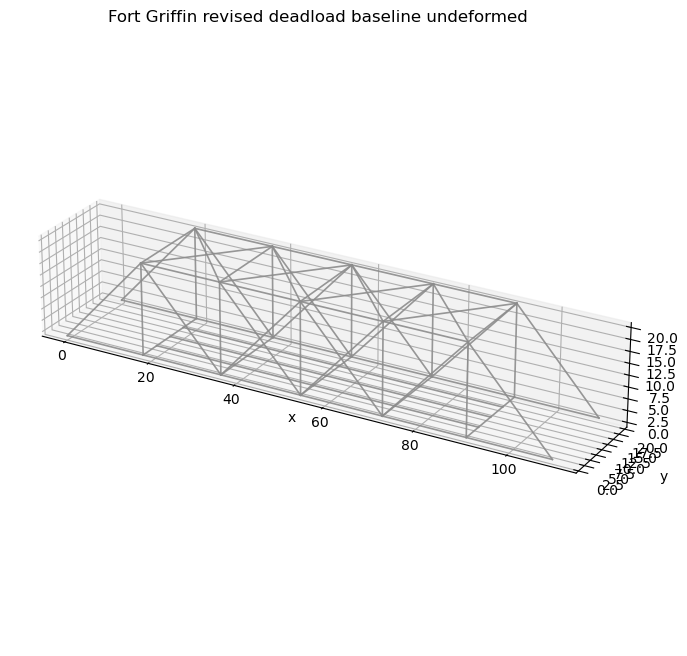

Saved outputs\final_bridge\simple_plots\fort_griffin_revised_deadload_undeformed.png


In [7]:
# simple plot 1
# undeformed only
# loads off

_ = plot_structure_simple(
    clean_model,
    data,
    U=None,
    scale=1.0,
    selector="all",
    show_undeformed=True,
    show_deformed=False,
    show_node_labels=False,
    show_element_labels=False,
    title="Fort Griffin revised deadload baseline undeformed",
    save_path=str(simple_undeformed),
)

print(f"Saved {simple_undeformed}")

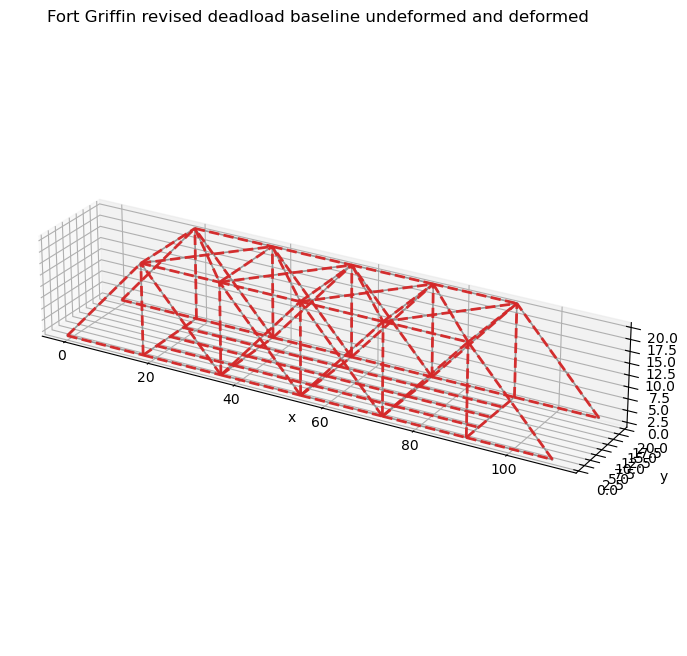

Saved outputs\final_bridge\simple_plots\fort_griffin_revised_deadload_undeformed_plus_deformed.png


In [8]:
# simple plot 2
# undeformed plus deformed
# loads off

_ = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=80.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=False,
    show_element_labels=False,
    title="Fort Griffin revised deadload baseline undeformed and deformed",
    save_path=str(simple_def_undef),
)

print(f"Saved {simple_def_undef}")

In [9]:
# plotly plot 1
# undeformed only
# loads off

fig_undef = plot_structure_plotly(
    clean_model,
    data,
    U=None,
    scale=1.0,
    selector="all",
    show_undeformed=True,
    show_deformed=False,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    show_member_loads=False,
    title="Fort Griffin revised deadload baseline undeformed",
    save_html=str(plotly_undef_html),
    save_png=str(plotly_undef_png),
)

fig_undef.show()

print(f"Saved {plotly_undef_html}")
print(f"Saved {plotly_undef_png}")

Saved outputs\final_bridge\plotly_plots\fort_griffin_revised_deadload_undeformed.html
Saved outputs\final_bridge\plotly_plots\fort_griffin_revised_deadload_undeformed.png


In [15]:
# plotly plot 2
# undeformed plus deformed
# loads off

fig_def = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=15000.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=False,
    show_member_loads=False,
    title="Fort Griffin revised deadload baseline undeformed and deformed",
    save_html=str(plotly_def_html),
    save_png=str(plotly_def_png),
)

fig_def.show()

print(f"Saved {plotly_def_html}")
print(f"Saved {plotly_def_png}")

Saved outputs\final_bridge\plotly_plots\fort_griffin_revised_deadload_undeformed_plus_deformed.html
Saved outputs\final_bridge\plotly_plots\fort_griffin_revised_deadload_undeformed_plus_deformed.png


In [11]:
# optional check of all saved files

print("Simple plots")
for p in sorted(plot_dir_simple.iterdir()):
    print(p)

print()
print("Plotly plots")
for p in sorted(plot_dir_plotly.iterdir()):
    print(p)

print()
print("Run output files")
for p in sorted(Path(output_dir).iterdir()):
    print(p.name)

Simple plots
outputs\final_bridge\simple_plots\fort_griffin_revised_baseline_undeformed.png
outputs\final_bridge\simple_plots\fort_griffin_revised_baseline_undeformed_plus_deformed.png
outputs\final_bridge\simple_plots\fort_griffin_revised_deadload_undeformed.png
outputs\final_bridge\simple_plots\fort_griffin_revised_deadload_undeformed_plus_deformed.png

Plotly plots
outputs\final_bridge\plotly_plots\final_01_baseline_full_bridge.html
outputs\final_bridge\plotly_plots\final_01_baseline_full_bridge.png
outputs\final_bridge\plotly_plots\final_02_baseline_floor_system_loads.html
outputs\final_bridge\plotly_plots\final_02_baseline_floor_system_loads.png
outputs\final_bridge\plotly_plots\final_03_missing_diagonal_full_bridge.html
outputs\final_bridge\plotly_plots\final_03_missing_diagonal_full_bridge.png
outputs\final_bridge\plotly_plots\final_04_weakened_floor_beam_full_bridge.html
outputs\final_bridge\plotly_plots\final_04_weakened_floor_beam_full_bridge.png
outputs\final_bridge\plotly_p

In [12]:
import pandas as pd

df_nodes = tables["node_displacements"].copy()

if "disp_mag" in df_nodes.columns:
    df_max_disp = df_nodes.sort_values("disp_mag", ascending=False)[
        ["node_id", "x", "y", "z", "ux", "uy", "uz", "disp_mag"]
    ].head(10)
else:
    df_nodes["disp_mag_calc"] = (df_nodes["ux"]**2 + df_nodes["uy"]**2 + df_nodes["uz"]**2) ** 0.5
    df_max_disp = df_nodes.sort_values("disp_mag_calc", ascending=False)[
        ["node_id", "x", "y", "z", "ux", "uy", "uz", "disp_mag_calc"]
    ].head(10)

display(df_max_disp)

,node_id,x,y,z,ux,uy,uz,disp_mag
31,32,54.528,10.0,0.0,0.000097,1.196857e-10,-0.000575,0.000583
32,33,54.528,15.0,0.0,0.000097,3.355061e-08,-0.000537,0.000546
30,31,54.528,5.0,0.0,0.000096,-3.331109e-08,-0.000535,0.000544
34,35,72.704,10.0,0.0,0.000090,1.277781e-10,-0.000520,0.000528
28,29,36.352,10.0,0.0,0.000103,4.459113e-11,-0.000514,0.000524
35,36,72.704,15.0,0.0,0.000105,2.893408e-08,-0.000483,0.000495
33,34,72.704,5.0,0.0,0.000105,-2.867797e-08,-0.000482,0.000493
15,16,54.528,20.0,0.0,0.000096,0.000000e+00,-0.000480,0.000490
3,4,54.528,0.0,0.0,0.000096,0.000000e+00,-0.000478,0.000488
29,30,36.352,15.0,0.0,0.000088,2.759198e-08,-0.000477,0.000485
